#### What is Parallelization in LangGraph?
What is Parallelization in LangGraph?
In LangGraph, nodes typically execute in a sequence defined by edges, but when tasks don’t depend on each other’s outputs, you can run them in parallel. This is achieved by:
-Defining multiple nodes that can operate independently.

-Connecting them to a common starting point (e.g., START or another node).

-Merging their outputs into a downstream node if needed.

LangGraph handles this implicitly when nodes are independent and can leverage multi-threading or asynchronous execution under the hood, depending on the runtime environment (e.g., Python’s asyncio or a multi-threaded executor).

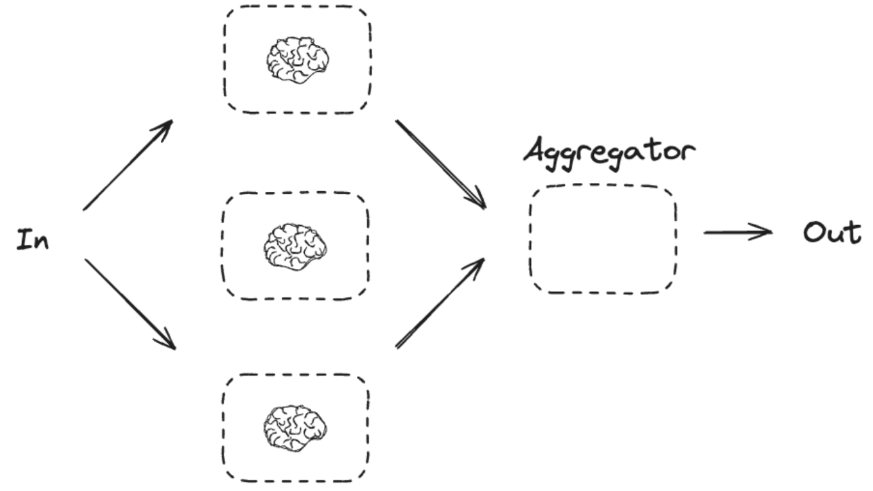

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="llama-3.1-8b-instant")
result = llm.invoke("Hello")
result


AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 36, 'total_tokens': 44, 'completion_time': 0.011659911, 'completion_tokens_details': None, 'prompt_time': 0.001779214, 'prompt_tokens_details': None, 'queue_time': 0.060104126, 'total_time': 0.013439125}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e40b8-42d6-7831-9ebc-492ae10b95f6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 8, 'total_tokens': 44})

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

# Graph state
class State(TypedDict):
    topic: str
    characters:str
    settings:str
    premises:str
    story_intro:str

In [7]:

# Nodes
def generate_characters(state: State) -> str:
    """Generate a character description"""
    msg = llm.invoke(f"Create two character names and brief traits for a story about {state['topic']} in Marathi")
    return {"characters": msg.content}

def generate_setting(state : State):
    """Generate a story setting"""
    msg = llm.invoke(f"Describe a vivid setting for a story about {state['topic']} in Marathi")
    return {"settings": msg.content}

def generate_premises(state : State):
    """Generate story premises"""
    msg = llm.invoke(f"Write a one sentence plot premise for a story about {state['topic']} in Marathi")
    return {"premises": msg.content}

def combine_elements(state : State):
    """Combine characters, setting, and premise into an intro"""
    msg = llm.invoke(
        f"Write a short story introduction using these elements in Marathi:\n"
        f"Characters: {state['characters']}\n"
        f"Setting: {state['settings']}\n"
        f"Premise: {state['premises']}\n")
    return {"story_intro": msg.content}
        


In [9]:
# Build the graph
graph = StateGraph(State)

graph.add_node("character", generate_characters)
graph.add_node("setting", generate_setting)
graph.add_node("premise", generate_premises)
graph.add_node("combine", combine_elements)


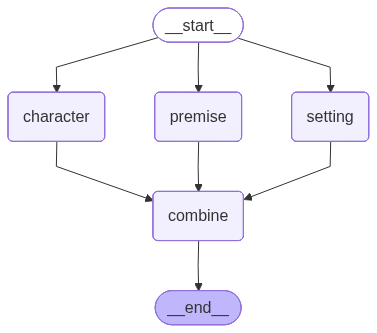

In [10]:
# Define edges (parallel execution from START)
graph.add_edge(START, "character")
graph.add_edge(START, "setting")
graph.add_edge(START, "premise")
graph.add_edge("character", "combine")
graph.add_edge("setting", "combine")
graph.add_edge("premise", "combine")
graph.add_edge("combine", END)

# Compile and run the graph
compiled_graph = graph.compile()
graph_image = compiled_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [12]:

state = {"topic": "crow and water"}
result = compiled_graph.invoke(state)
print(result["story_intro"])

"मावळाच्या पायवाटेतून फुलांचा सुगंध येत होता आणि झरीचे पाणी चांगले कळवळत होते. निरंक आणि कैलास हे दोघेही तलावाजवळच्या झाडांवर फुले झांकत असताना पाहिल्यानंतर त्यांच्या डोळ्यात खूपसारे आनंद आहे. ते दोघेही एका छोट्याशा मोठ्या काळ्या कावळ्याच्या बारीक सुरुवातीच्या प्रयत्नावर लक्ष केंद्रित करू लागले. क्रौंच हा त्याच्या मोठ्या झाडाच्या डोक्यावर एक छोटी झाडे आणि फुले झालेली आहेत आणि तो त्याच्या जोडीदाराला पाण्यात तळत असताना त्याच्या पंखांचा तेजस्वी रंग सोनेरी झालेल्या सूर्याच्या प्रकाशात दिसत आहे.

कैलास हा एक कुशल निर्माता आणि निरंकचा जुना मित्र असतो. तो निरंकच्यासोबत पाण्यासाठी काम करत असताना काही नवीन आणि आश्चर्यकारक विचारांनी त्याला प्रेरित करतो. कैलास हा असे विचार करू लागला की क्रौंचाच्या बारीक प्रयत्नांमुळे तलावाच्या एका मोठ्या भागाला पुनरुज्जीवन देण्याची संधी आहे.

निरंक हा एक सावित्रीरित्या आणि स्वच्छ पाण्याचा शौकीन असतो. तो संपूर्ण गावात पाणी पुरवण्यासाठी काम करत असताना त्याचा प्रेमाचा मित्र एक मोठा कांगारू आहे. तो कैलासच्या विचारांना प्रेरित झाला आणि त्याने क्रौंचाला तलावाच्या एका म


#### Key Benefits
-Speed: Reduces total execution time by running tasks concurrently.

-Scalability: Handles larger workflows efficiently.

-Modularity: Keeps the graph structure clean and reusable.

#### Key Takeaways
-When to Parallelize: Use it for independent tasks (e.g., generating multiple outputs, checking separate inputs).

-Merging: Downstream nodes can aggregate parallel results.

-LangGraph Support: The framework naturally supports this by waiting for all required inputs before proceeding.